# SME DataPrep Python examples

This notebook illustrates the package with the Titanic training dataset stored in `data/titanic/train.csv`. The target variable is `Survived`, where `1` means the passenger survived and `0` means they did not.

## Goal

The objective of this notebook is to show how the functions in the package can be used to preprocess and describe a real dataset. The Titanic dataset is useful for this first example because it combines numerical variables such as `Age` and `Fare`, categorical variables such as `Sex` and `Embarked`, and a binary supervised target, `Survived`.

The examples are deliberately written step by step. For each group of functions, the notebook explains what the method measures, why it is useful in data preprocessing, and how the implemented function calculates it.

## Setup

In [1]:
# Install the local package in editable mode for this notebook kernel.
# The sys.path line makes the import work immediately, even before restarting
# the kernel after installation.
%pip install -e ./package -q

from pathlib import Path
import sys

import pandas as pd

package_path = Path.cwd() / "package"
if str(package_path) not in sys.path:
    sys.path.insert(0, str(package_path))

from dataprepkit import (
    DataPrepDataset,
    compare_auc_values,
    association_matrix,
    attribute_metrics,
    discretize_equal_width,
    discretize_dataset_equal_frequency,
    discretize_dataset_equal_width,
    entropy,
    filter_variables,
    normalize_dataset,
    plot_association_matrix,
    plot_roc_curve,
    standardize_dataset,
)


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Data

The Titanic training file has passenger-level information and the binary outcome `Survived`. A value of `1` means that the passenger survived and a value of `0` means that the passenger did not survive.

For this first example, we keep a focused set of variables. `Age`, `SibSp`, `Parch`, and `Fare` are treated as numerical variables. `Pclass`, `Sex`, and `Embarked` are treated as categorical variables. `Pclass` appears as a number in the CSV file, but it represents first, second, or third passenger class, so it is more meaningful to handle it as a category.

Columns such as `PassengerId`, `Name`, `Ticket`, and `Cabin` are not used in this first walkthrough. They contain identifiers or high-cardinality text values, which are less useful for explaining the required preprocessing functions clearly.

In [2]:
data_path = Path("data/titanic/train.csv")
raw_data = pd.read_csv(data_path)

analysis_data = raw_data[[
    "Survived",
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
]].copy()

# Pclass is numeric in the CSV, but conceptually it is a passenger class category.
analysis_data["Pclass"] = analysis_data["Pclass"].astype("category")
analysis_data["Survived"] = analysis_data["Survived"].astype(int)

dataset = DataPrepDataset(analysis_data, target="Survived")
analysis_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [3]:
analysis_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    category
 2   Sex       891 non-null    str     
 3   Age       714 non-null    float64 
 4   SibSp     891 non-null    int64   
 5   Parch     891 non-null    int64   
 6   Fare      891 non-null    float64 
 7   Embarked  889 non-null    str     
dtypes: category(1), float64(2), int64(3), str(2)
memory usage: 49.7 KB


## Steps

### 1. Attribute metrics

The function `attribute_metrics` chooses a metric according to the type of each variable. For numerical variables, it computes variance and, when a binary target is provided, AUC. For categorical variables, it computes entropy.

Variance measures how spread out a numerical variable is around its mean. A variable with variance close to zero has almost the same value for every row, so it usually contains little information.

Entropy measures the uncertainty or diversity of a categorical variable. If almost all passengers have the same category, entropy is low. If the categories are more evenly distributed, entropy is higher.

AUC means Area Under the ROC Curve. In this package it is implemented from pairwise comparisons: every survivor is compared with every non-survivor. If the survivor has a higher value for the numerical attribute, it counts as a win; if both values are equal, it counts as half a win. The final AUC is the proportion of wins over all possible survivor/non-survivor pairs. An AUC of 0.5 means the attribute is not better than random ordering, while values closer to 1 mean higher values of the attribute are more associated with survival.

In [4]:
metrics = attribute_metrics(analysis_data, target="Survived", positive_class=1)
metrics

,attribute,metric,value
0,Pclass,entropy,1.439321
1,Sex,entropy,0.936205
2,Age,variance,210.723580
3,Age,auc,0.469112
4,SibSp,variance,1.214678
5,SibSp,auc,0.543162
6,Parch,variance,0.648999
7,Parch,auc,0.561217
8,Fare,variance,2466.665312
9,Fare,auc,0.692122


### 2. Equal-width and equal-frequency discretization

Discretization converts a numerical variable into a categorical one by placing values into intervals or bins. This is useful when an algorithm or a metric expects discrete values, or when we want to simplify a continuous variable for interpretation.

Equal-width discretization divides the range between the minimum and maximum value into intervals of the same size. For example, the width of each `Age` interval is determined by the age range divided by the number of bins.

Equal-frequency discretization sorts the observations and creates bins with approximately the same number of rows. This means the numerical width of the bins can be different, but their frequency is more balanced.

In [5]:
numeric_features = ["Age", "SibSp", "Parch", "Fare"]

equal_width_data = discretize_dataset_equal_width(analysis_data[numeric_features], bins=4)
equal_frequency_data = discretize_dataset_equal_frequency(analysis_data[numeric_features], bins=4)

equal_width_data.head()

,Age,SibSp,Parch,Fare
0,bin_2,bin_1,bin_1,bin_1
1,bin_2,bin_1,bin_1,bin_1
2,bin_2,bin_1,bin_1,bin_1
3,bin_2,bin_1,bin_1,bin_1
4,bin_2,bin_1,bin_1,bin_1


In [6]:
equal_frequency_data.head()

,Age,SibSp,Parch,Fare
0,bin_2,bin_3,bin_1,bin_1
1,bin_3,bin_3,bin_1,bin_4
2,bin_2,bin_1,bin_1,bin_2
3,bin_3,bin_3,bin_1,bin_4
4,bin_3,bin_1,bin_1,bin_2


### 3. Normalization and standardization

Normalization and standardization are transformations for numerical variables. They do not change the order of the observations, but they change the scale.

Normalization rescales a variable to the interval `[0, 1]`. The minimum value becomes 0 and the maximum value becomes 1. This is useful when variables have very different units, such as age in years and fare in pounds.

Standardization subtracts the mean and divides by the standard deviation. After this transformation, the variable has mean 0 and standard deviation 1. This is useful when we want to compare variables on a common scale while preserving how far each observation is from the average.

In [7]:
normalized_features = normalize_dataset(analysis_data[numeric_features])
standardized_features = standardize_dataset(analysis_data[numeric_features])

normalized_features.head()

,Age,SibSp,Parch,Fare
0,0.271174,0.125,0.0,0.014151
1,0.472229,0.125,0.0,0.139136
2,0.321438,0.000,0.0,0.015469
3,0.434531,0.125,0.0,0.103644
4,0.434531,0.000,0.0,0.015713


In [8]:
standardized_features.head()

,Age,SibSp,Parch,Fare
0,-0.530377,0.432793,-0.473674,-0.502445
1,0.571831,0.432793,-0.473674,0.786845
2,-0.254825,-0.474545,-0.473674,-0.488854
3,0.365167,0.432793,-0.473674,0.420730
4,0.365167,-0.474545,-0.473674,-0.486337


### 4. Variable filtering

Variable filtering uses the metrics calculated earlier to keep only variables that satisfy a threshold. This is a simple preprocessing strategy for reducing a dataset before later analysis.

In this example, we keep numerical variables whose AUC is at least 0.55. The threshold is intentionally modest because a single Titanic variable is not expected to perfectly separate survivors from non-survivors. The goal is to show the mechanism: calculate a metric for each variable, compare it with a threshold, and return a new dataset with the variables that pass the rule.

In [9]:
filtered_by_auc = filter_variables(
    analysis_data,
    metric="auc",
    threshold=0.55,
    target="Survived",
    positive_class=1,
)
filtered_by_auc.head()

,Parch,Fare,Survived
0,0,7.2500,0
1,0,71.2833,1
2,0,7.9250,1
3,0,53.1000,1
4,0,8.0500,0


### 5. Pairwise association matrix

The function `association_matrix` compares variables two by two. The measure depends on the types of the pair.

For two numerical variables, the package calculates Pearson correlation. This measures linear association and returns values between -1 and 1. A value near 1 means both variables tend to increase together, a value near -1 means one tends to decrease when the other increases, and a value near 0 means there is little linear association.

For two categorical variables, the package calculates mutual information. Mutual information measures how much knowing one variable reduces uncertainty about the other. It is computed from entropy: the entropy of each variable is compared with the entropy of their joint distribution.

For mixed numerical-categorical pairs, the matrix returns missing values in this first version, because the assignment specifically asks for correlation for numerical variables and mutual information for categorical variables.

In [10]:
association_features = analysis_data[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
matrix = association_matrix(association_features)
matrix

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Pclass,1.439321,0.013710,NaN,NaN,NaN,NaN,0.102142
Sex,0.013710,0.936205,NaN,NaN,NaN,NaN,0.010617
Age,NaN,NaN,1.000000,-0.308247,-0.189119,0.096067,NaN
SibSp,NaN,NaN,-0.308247,1.000000,0.414838,0.159651,NaN
Parch,NaN,NaN,-0.189119,0.414838,1.000000,0.216225,NaN
Fare,NaN,NaN,0.096067,0.159651,0.216225,1.000000,NaN
Embarked,0.102142,0.010617,NaN,NaN,NaN,NaN,1.096869


## Checks

The ROC curve is the specific plot associated with AUC. It shows the tradeoff between true positive rate and false positive rate for all possible thresholds of one numerical attribute. Here we draw the ROC curve for `Fare` as an example.

The barplot created by `compare_auc_values` is different: it summarizes and compares the final AUC values of several numerical attributes in one figure.

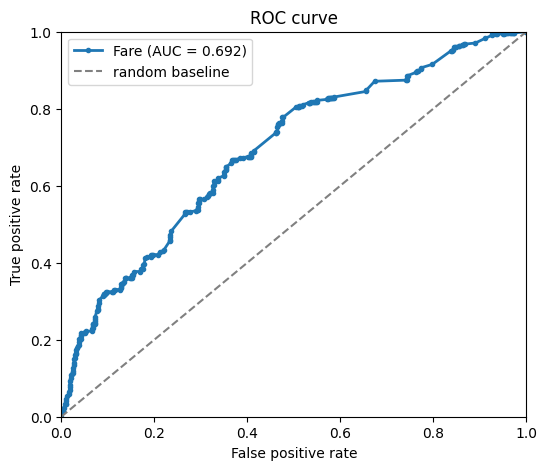

In [11]:
plot_roc_curve(analysis_data["Fare"], analysis_data["Survived"], positive_class=1, label="Fare");

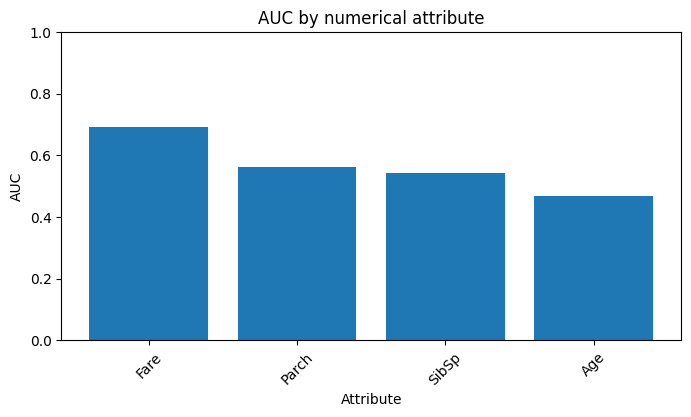

In [12]:
compare_auc_values(analysis_data, target="Survived", positive_class=1);

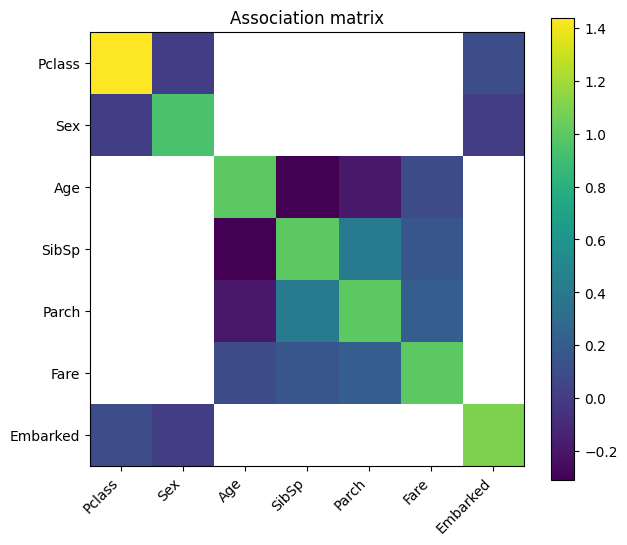

In [13]:
plot_association_matrix(matrix);

## Next Steps

When the second dataset is added, repeat the same workflow in a new section: load the data, identify the binary target, choose meaningful numerical/categorical variables, and show the same functions again.